# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [26]:
import numpy as np
import seaborn as sns
import pandas as pd

/var/folders/hb/x2mhw6jn7x35b5xw13m920y00000gn/T/ipykernel_71839/2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

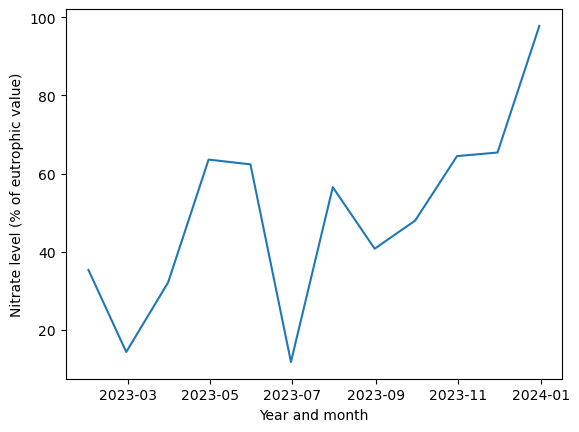

In [27]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

/var/folders/hb/x2mhw6jn7x35b5xw13m920y00000gn/T/ipykernel_71839/1726504607.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

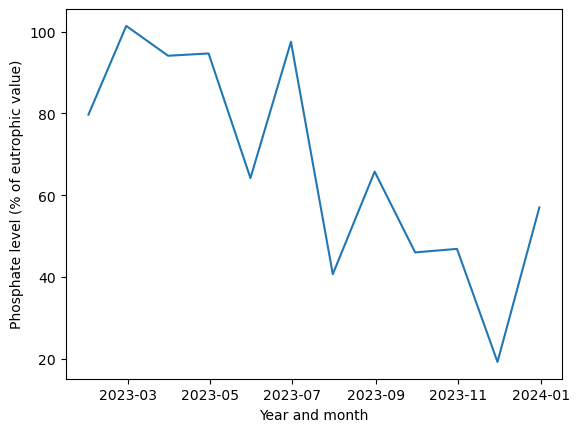

In [28]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

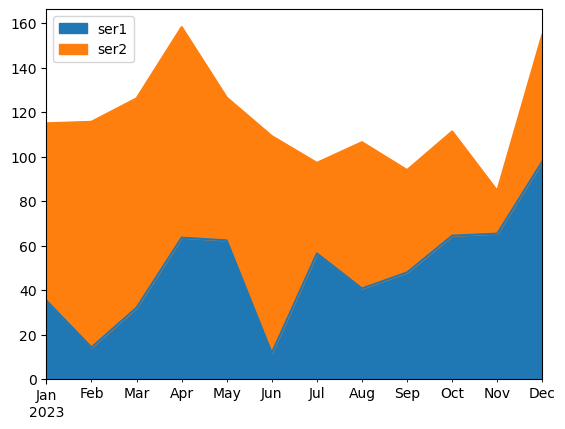

In [29]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

Using an area plot to display nitrate and phosphate levels emphasizes total nutrient load over time. Because the areas are stacked, it highlights the combined environmental impact and visually shows how each nutrient contributes to the overall level. This can be helpful when the goal is to emphasize magnitude or cumulative effect.

However, area plots make it harder to compare precise individual trends. In the stacked version, the top series (phosphate) is visually influenced by the nitrate values beneath it, which can distort perception of its independent fluctuations. Line graphs are better for identifying peaks, rate of change, and exact differences between nutrients.

To improve the visualization, I would replace generic legend labels (e.g., “ser1” and “ser2”) with descriptive names, rotate x-axis labels for readability, add a grid for interpretability, and include a clear title. Combining both nutrients as two lines on a single plot may also provide clearer comparison without visual distortion.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [30]:
import matplotlib.pyplot as plt

Loading and Cleaning Data

In [31]:
kff = pd.read_csv('raw_data.csv', skiprows=2)  
census = pd.read_csv("acs2017_county_data.csv") 

In [32]:
# Remove United States row
kff = kff[kff["Location"] != "United States"]

# Convert total prevalence to numeric
kff["Total (Age-Adjusted)"] = pd.to_numeric(kff["Total (Age-Adjusted)"], errors="coerce")

In [33]:
kff = kff.rename(columns={
    "Location": "State",
    "Total (Age-Adjusted)": "DiabetesRate"
})

In [34]:
state_census = census.groupby("State").agg({
    "IncomePerCap": "mean",
    "Poverty": "mean",
    "TotalPop": "sum"
}).reset_index()

Merged Dataset

In [35]:
merged = pd.merge(kff, state_census, on="State", how="inner")

print(merged.head())

        State Ages 18-44 Ages 45-64 Ages 65-74 Ages 75+  DiabetesRate  \
0     Alabama      0.041      0.178      0.283    0.252         0.120   
1      Alaska        NSD      0.116      0.198    0.207         0.078   
2     Arizona      0.027      0.139      0.200    0.215         0.091   
3    Arkansas      0.029      0.191      0.239    0.228         0.112   
4  California      0.028      0.137      0.240    0.230         0.096   

   IncomePerCap    Poverty  TotalPop  
0  22180.492537  20.949254   4850771  
1  31670.551724  13.555172    738565  
2  22712.200000  20.193333   6809946  
3  21449.306667  20.421333   2977944  
4  30416.482759  15.737931  38982847  


In [36]:
print(merged.shape)
print(merged.isna().sum())

(52, 9)
State           0
Ages 18-44      0
Ages 45-64      0
Ages 65-74      0
Ages 75+        0
DiabetesRate    0
IncomePerCap    0
Poverty         0
TotalPop        0
dtype: int64


In [37]:
merged = merged[merged["State"] != "Puerto Rico"]

Bivariate Analysis

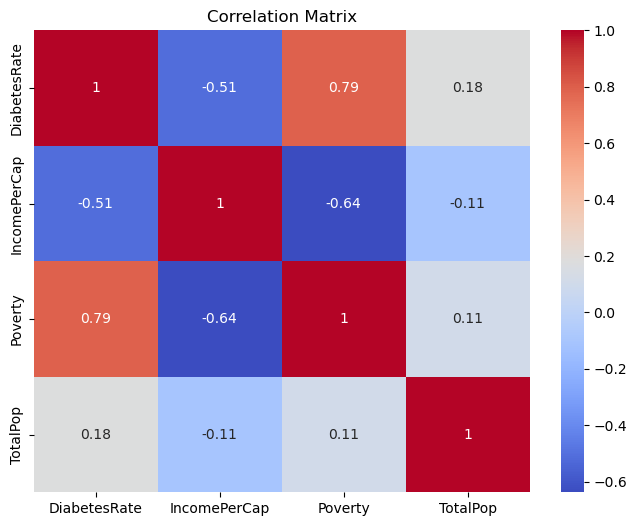

In [38]:
corr = merged.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [39]:
merged.dtypes

State            object
Ages 18-44       object
Ages 45-64       object
Ages 65-74       object
Ages 75+         object
DiabetesRate    float64
IncomePerCap    float64
Poverty         float64
TotalPop          int64
dtype: object

In [40]:
age_cols = ["Ages 18-44", "Ages 45-64", "Ages 65-74", "Ages 75+"]

for col in age_cols:
    merged[col] = pd.to_numeric(merged[col], errors="coerce")

In [41]:
merged[age_cols].dtypes

Ages 18-44    float64
Ages 45-64    float64
Ages 65-74    float64
Ages 75+      float64
dtype: object

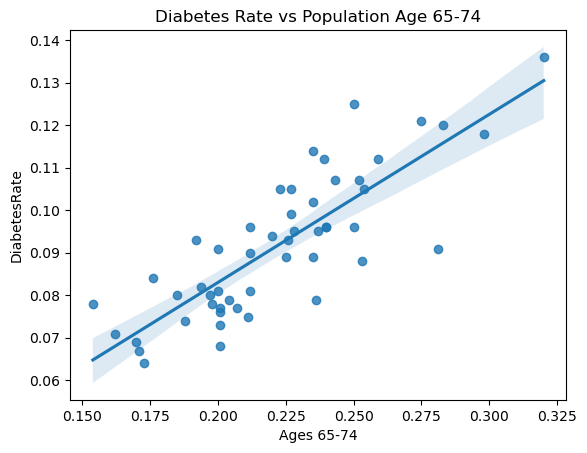

In [42]:
sns.regplot(x="Ages 65-74", y="DiabetesRate", data=merged)
plt.title("Diabetes Rate vs Population Age 65-74")
plt.show()

<Axes: xlabel='Ages 18-44', ylabel='DiabetesRate'>

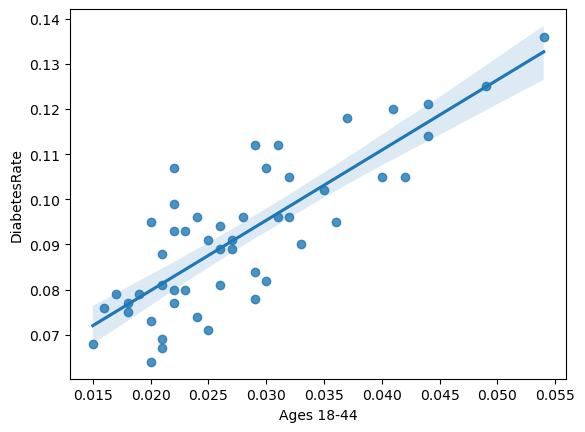

In [43]:
sns.regplot(x="Ages 18-44", y="DiabetesRate", data=merged)

In [44]:
merged[["IncomePerCap", "Poverty"]].corr()

,IncomePerCap,Poverty
IncomePerCap,1.000000,-0.637748
Poverty,-0.637748,1.000000


In [45]:
merged[["Ages 65-74", "DiabetesRate"]].corr()

,Ages 65-74,DiabetesRate
Ages 65-74,1.000000,0.828108
DiabetesRate,0.828108,1.000000


In [46]:
merged.sort_values("Ages 65-74", ascending=False)[["State","Ages 65-74","DiabetesRate"]].head(5)
merged.sort_values("DiabetesRate", ascending=False)[["State","Ages 65-74","DiabetesRate"]].head(5)

,State,Ages 65-74,DiabetesRate
24,Mississippi,0.320,0.136
48,West Virginia,0.250,0.125
17,Kentucky,0.275,0.121
0,Alabama,0.283,0.120
18,Louisiana,0.298,0.118


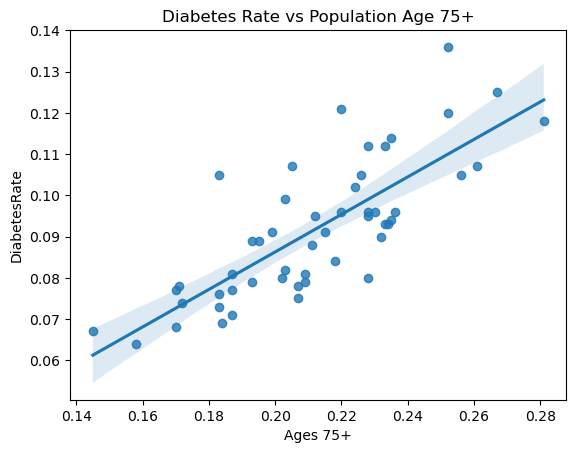

In [47]:
sns.regplot(x="Ages 75+", y="DiabetesRate", data=merged)
plt.title("Diabetes Rate vs Population Age 75+")
plt.show()

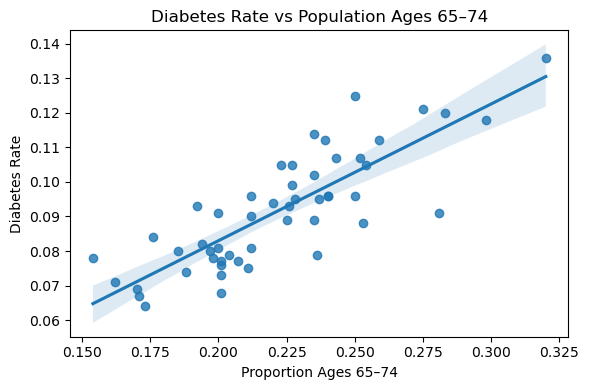

In [53]:
plt.figure(figsize=(6,4))
sns.regplot(x="Ages 65-74", y="DiabetesRate", data=merged)
plt.title("Diabetes Rate vs Population Ages 65–74")
plt.xlabel("Proportion Ages 65–74")
plt.ylabel("Diabetes Rate")
plt.tight_layout()
plt.show()

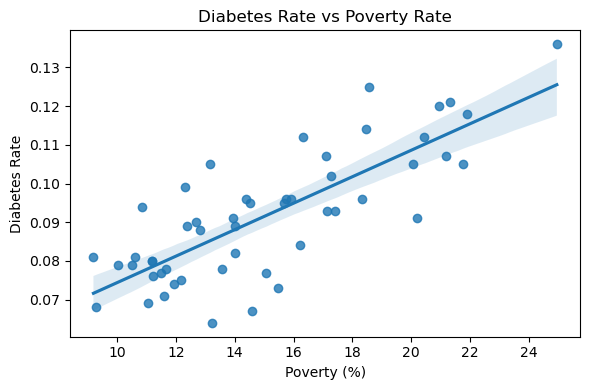

In [50]:
plt.figure(figsize=(6,4))
sns.regplot(x="Poverty", y="DiabetesRate", data=merged)
plt.title("Diabetes Rate vs Poverty Rate")
plt.xlabel("Poverty (%)")
plt.ylabel("Diabetes Rate")
plt.tight_layout()
plt.show()

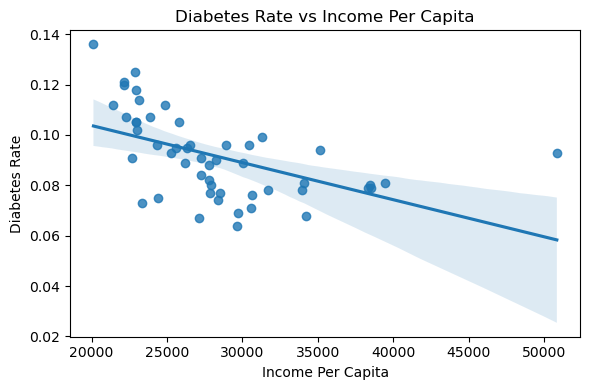

In [51]:
plt.figure(figsize=(6,4))
sns.regplot(x="IncomePerCap", y="DiabetesRate", data=merged)
plt.title("Diabetes Rate vs Income Per Capita")
plt.xlabel("Income Per Capita")
plt.ylabel("Diabetes Rate")
plt.tight_layout()
plt.show()

Conclusion:

The correlation analysis reveals several meaningful relationships between demographic and socioeconomic variables and state-level diabetes prevalence. Poverty shows a strong positive correlation with DiabetesRate (r ≈ 0.78), suggesting that states with higher poverty levels tend to experience higher diabetes prevalence. Income per capita is moderately negatively correlated with DiabetesRate (r ≈ -0.59), indicating that wealthier states generally report lower diabetes rates. Income and poverty themselves are strongly negatively correlated (r ≈ -0.68), suggesting potential redundancy between these socioeconomic indicators and raising concerns about multicollinearity if both were included in a predictive model.

Age structure appears to be an especially important factor. The proportion of residents aged 65–74 shows a very strong positive correlation with DiabetesRate (r ≈ 0.86), and similar positive patterns are observed for the 75+ age group. These findings suggest that states with older populations tend to have higher diabetes prevalence, which is consistent with biological expectations regarding age and chronic disease risk.

Because age composition, income, and poverty are interrelated at the state level, age may act as a confounding variable in the relationship between poverty and diabetes. While strong associations are observed, these findings are based on observational correlations and do not imply causation. Overall, the results suggest that both demographic structure and socioeconomic conditions are closely associated with variation in diabetes prevalence across states.

Limitations:

This analysis is based on aggregated state-level data, which introduces the possibility of ecological fallacy, meaning relationships observed at the state level may not reflect individual-level risk. Additionally, correlation does not establish causation, and unmeasured factors such as healthcare access, urbanization, diet patterns, or racial and ethnic composition may influence both socioeconomic conditions and diabetes prevalence. Finally, because many predictors are interrelated (e.g., income, poverty, and age structure), more advanced modeling would be required to isolate independent effects.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

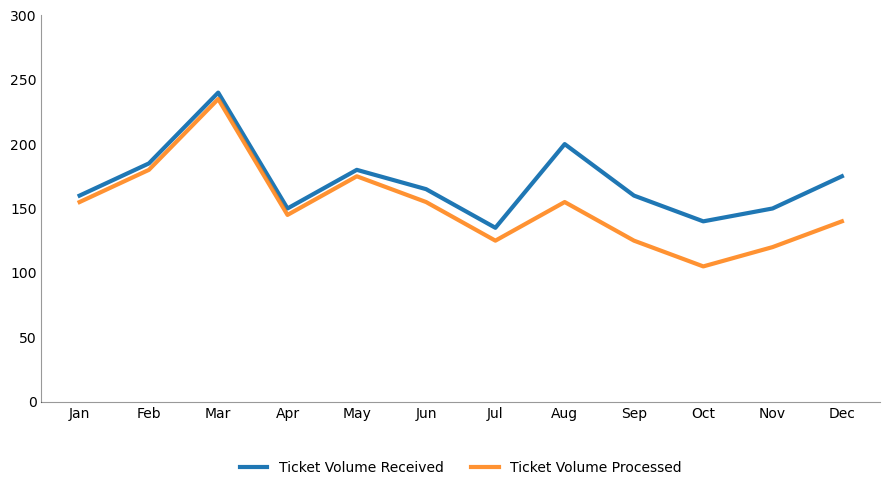

In [48]:
months = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]

received = [160, 185, 240, 150, 180, 165, 135, 200, 160, 140, 150, 175]
processed = [155, 180, 235, 145, 175, 155, 125, 155, 125, 105, 120, 140]

df = pd.DataFrame({
    "Month": months,
    "Ticket Volume Received": received,
    "Ticket Volume Processed": processed
})

plt.figure(figsize=(9,5))

# Plot lines with intentional hierarchy
plt.plot(df["Month"], df["Ticket Volume Received"],
         linewidth=3, label="Ticket Volume Received")

plt.plot(df["Month"], df["Ticket Volume Processed"],
         linewidth=3, alpha=0.85,
         label="Ticket Volume Processed")


# Remove unnecessary axis titles
plt.xlabel("")
plt.ylabel("")

# Set y-axis range and ticks (no trailing decimals)
plt.ylim(0, 300)
plt.yticks([0, 50, 100, 150, 200, 250, 300])

# Remove grid
plt.grid(False)

# Remove top and right spines
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Lighten remaining spines
ax.spines["left"].set_alpha(0.4)
ax.spines["bottom"].set_alpha(0.4)

# Remove tick marks (cleaner look)
ax.tick_params(axis='both', which='both', length=0)


plt.legend(loc="upper center",
           bbox_to_anchor=(0.5, -0.12),
           ncol=2,
           frameon=False)

# Tight layout to prevent clipping
plt.tight_layout()

plt.show()